# AP_plots
AFM force-curve analysis pipeline for Asylum Research `.ibw` files.

**Workflow:**
1. Load config & resolve per-run data paths from the `experiment` field
2. Load a single curve and inspect the DataFrame
3. Plot approach vs. retract for a single file
4. Average key indices across sweeps for each force setpoint
5. Build a results DataFrame and plot ΔDefl vs. ΔZ
6. Fit Force vs. ΔDefl to extract the spring constant *k*

## Imports

In [231]:
import glob
import os
import re

import igor2.binarywave as bw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import linregress
import plotly.graph_objects as go

## Step 1 – Load config & resolve paths

`AP_runs.yaml` lives in the master folder. Each run entry has an `experiment` field (e.g. `AP_1`) that points to its subfolder. Raw `.ibw` files are read directly from `<master>/<experiment>/raw/`.

In [232]:
# Master folder that contains AP_runs.yaml and all AP_* experiment subfolders
MASTER_DIR = '/Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/'
YAML_FILE  = os.path.join(MASTER_DIR, 'AP_runs.yaml')

with open(YAML_FILE, 'r') as f:
    config = yaml.safe_load(f)

def raw_dir(run):
    """Return the raw/ directory for a given run, derived from its 'experiment' field."""
    experiment = config[run]['experiment']   # e.g. 'AP_1'
    return os.path.join(MASTER_DIR, experiment, 'raw')

# Quick sanity check
for run in config:
    print(f'{run}  →  {raw_dir(run)}')

run_FD  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/raw
run_FD2  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/raw
run_FD3  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_2/raw
run_FD4  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD5  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD6  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD7  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_3/raw
run_FD8  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_4/raw
run_FD9  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_4/raw
run_FD10  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_4/raw
run_FD11  →  /Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_4/raw
run_FD12 

## Helper functions

In [233]:
def load_ibw(filepath):
    """Return (DataFrame, metadata-dict) for an Asylum .ibw file."""
    data   = bw.load(filepath)
    wave   = data['wave']
    labels = [l.decode() for l in wave['labels'][1] if l]
    df     = pd.DataFrame(wave['wData'], columns=labels)

    meta = {}
    for line in wave['note'].decode('latin-1').split('\r'):
        if ':' in line:
            key, _, val = line.partition(':')
            meta[key.strip()] = val.strip()

    return df, meta


def parse_force_to_N(force_str):
    """
    Convert a force string to Newtons.
    Accepts 'p' as a decimal separator (e.g. '1p2uN' -> 1.2e-6 N)
    and plain integer values (e.g. '10uN', '500nN').
    """
    normalised = force_str.replace('p', '.')
    val, unit  = re.match(r'([\d.]+)(nN|uN)', normalised).groups()
    return float(val) * (1e-9 if unit == 'nN' else 1e-6)

def get_curve_indices(filepath, defl_threshold_nm=2, window=50):
    df, _ = load_ibw(filepath)

    defl = df['Defl'].to_numpy() * 1e9  # → nm

    # Right edge: global maximum
    idx_max = int(np.argmax(defl))

    # Rolling mean of deflection (only up to idx_max)
    defl_series  = pd.Series(defl[:idx_max])
    rolling_mean = defl_series.rolling(window=window, min_periods=1).mean().to_numpy()

    # Left edge: first point where deflection rises more than threshold above local rolling mean
    diff = defl[:idx_max] - rolling_mean
    spike_start = np.where(diff > defl_threshold_nm)[0]
    idx_min = int(spike_start[0]) if len(spike_start) > 0 else 0

    return [idx_min], [idx_max]

def get_average_indices(run, acquisition):
    """
    Average DeltaDefl and DeltaZ across all sweeps for a given run/force setpoint.
    Returns a dict {'delta_defl': float, 'delta_z': float}, or None if no files found.
    """
    data_dir = raw_dir(run)
    pattern  = os.path.join(glob.escape(data_dir), f'{run}_{acquisition}_*.ibw')
    files    = glob.glob(pattern)

    if not files:
        print(f'  [warn] No files found for {run}  {acquisition}')
        return None

    all_start_defl, all_lg_defl = [], []
    all_start_z,    all_lg_z    = [], []

    for fp in files:
        df, _          = load_ibw(fp)
        [idx_min], [idx_max] = get_curve_indices(fp)

        all_start_defl.append(df['Defl'].iloc[idx_min])
        all_lg_defl.append(df['Defl'].iloc[idx_max])

        all_start_z.append(df['ZSnsr'].iloc[idx_min])
        all_lg_z.append(df['ZSnsr'].iloc[idx_max])

    return {
        'delta_defl': np.mean(all_lg_defl) - np.mean(all_start_defl),
        'delta_z':    np.mean(all_lg_z)    - np.mean(all_start_z),
    }

## Step 2 – Inspect a single file

In [234]:
EXAMPLE_RUN  = 'run_FD13'
EXAMPLE_FILE = 'run_FD13_1uN_0008.ibw'
example_path = os.path.join(raw_dir(EXAMPLE_RUN), EXAMPLE_FILE)

df_example, meta_example = load_ibw(example_path)
df_example.head()

,Raw,Defl,ZSnsr
0,0.000005,1.878282e-09,0.000005
1,0.000005,1.880970e-09,0.000005
2,0.000005,1.886349e-09,0.000005
3,0.000005,1.884120e-09,0.000005
4,0.000005,1.880935e-09,0.000005


## Step 3 – Plot approach vs. retract for the example file

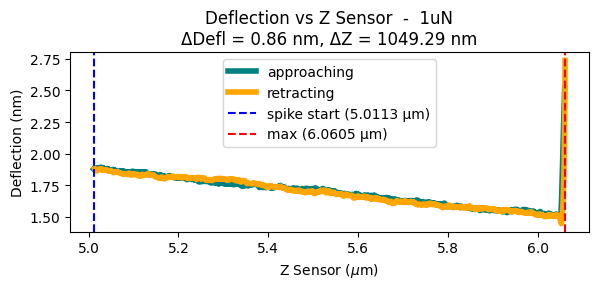

In [235]:
force_raw   = EXAMPLE_FILE.split('_')[2]
force_label = force_raw.replace('p', '.')

[idx_min], [idx_max] = get_curve_indices(example_path)

x_approach = df_example['ZSnsr'].iloc[:idx_max] * 1e6
y_approach = df_example['Defl'].iloc[:idx_max]  * 1e9
x_retract  = df_example['ZSnsr'].iloc[idx_max:] * 1e6
y_retract  = df_example['Defl'].iloc[idx_max:]  * 1e9

z_min = df_example['ZSnsr'].iloc[idx_min] * 1e6
z_max = df_example['ZSnsr'].iloc[idx_max] * 1e6

delta_defl = (df_example['Defl'].iloc[idx_max] - df_example['Defl'].iloc[idx_min]) * 1e9
delta_z    = (df_example['ZSnsr'].iloc[idx_max] - df_example['ZSnsr'].iloc[idx_min]) * 1e9

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x_approach, y_approach, color='teal',   linewidth=4)
ax.plot(x_retract,  y_retract,  color='orange', linewidth=4)
ax.axvline(z_min, color='blue', linestyle='--', linewidth=1.5, label=f'spike start ({z_min:.4f} µm)')
ax.axvline(z_max, color='red',  linestyle='--', linewidth=1.5, label=f'max ({z_max:.4f} µm)')

ax.legend(handles=[
    plt.Line2D([0], [0], color='teal',   linewidth=4,                  label='approaching'),
    plt.Line2D([0], [0], color='orange', linewidth=4,                  label='retracting'),
    plt.Line2D([0], [0], color='blue',   linestyle='--', linewidth=1.5, label=f'spike start ({z_min:.4f} µm)'),
    plt.Line2D([0], [0], color='red',    linestyle='--', linewidth=1.5, label=f'max ({z_max:.4f} µm)'),
])
ax.set_xlabel(r'Z Sensor ($\mu$m)')
ax.set_ylabel(r'Deflection (nm)')
ax.set_title(f'Deflection vs Z Sensor  -  {force_label}\nΔDefl = {delta_defl:.2f} nm, ΔZ = {delta_z:.2f} nm')
plt.tight_layout()

In [236]:
force_raw   = EXAMPLE_FILE.split('_')[2]
force_label = force_raw.replace('p', '.')

[idx_min], [idx_max] = get_curve_indices(example_path)

x_approach = df_example['ZSnsr'].iloc[:idx_max] * 1e6
y_approach = df_example['Defl'].iloc[:idx_max]  * 1e9
x_retract  = df_example['ZSnsr'].iloc[idx_max:] * 1e6
y_retract  = df_example['Defl'].iloc[idx_max:]  * 1e9

z_min = df_example['ZSnsr'].iloc[idx_min] * 1e6
z_max = df_example['ZSnsr'].iloc[idx_max] * 1e6

delta_defl = (df_example['Defl'].iloc[idx_max] - df_example['Defl'].iloc[idx_min]) * 1e9
delta_z    = (df_example['ZSnsr'].iloc[idx_max] - df_example['ZSnsr'].iloc[idx_min]) * 1e9

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_approach, y=y_approach, mode='lines', name='approaching',
                         line=dict(color='orange', width=8)))
fig.add_trace(go.Scatter(x=x_retract, y=y_retract, mode='lines', name='retracting',
                         line=dict(color='teal', width=8)))

y_range = [min(y_approach.min(), y_retract.min()), max(y_approach.max(), y_retract.max())]
fig.add_trace(go.Scatter(x=[z_min, z_min], y=y_range, mode='lines', name=f'spike start ({z_min:.4f} µm)',
                         line=dict(color='blue', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=[z_max, z_max], y=y_range, mode='lines', name=f'max ({z_max:.4f} µm)',
                         line=dict(color='red', width=1.5, dash='dash')))

fig.update_layout(
    title=f'Deflection vs Z Sensor  -  {force_label}<br><sup>ΔDefl = {delta_defl:.2f} nm  |  ΔZ = {delta_z:.2f} nm</sup>',
    xaxis=dict(title='Z Sensor (µm)'),
    yaxis=dict(title='Deflection (nm)'),
)
print(z_min, z_max)
fig.show()

5.0112543 6.0605493


## Step 4 – Build results DataFrame

In [237]:
config.keys() 

dict_keys(['run_FD', 'run_FD2', 'run_FD3', 'run_FD4', 'run_FD5', 'run_FD6', 'run_FD7', 'run_FD8', 'run_FD9', 'run_FD10', 'run_FD11', 'run_FD12', 'run_FD13', 'run_FD14', 'run_FD15', 'run_FD16', 'run_FD17', 'run_FD18', 'run_FD19', 'run_FD20', 'run_FD21', 'run_FD22', 'run_FD23', 'run_FD24', 'run_FD25', 'run_FD26', 'run_FD27', 'run_FD28'])

In [238]:
rows = []
#runs_of_interest = config.keys()  # all runs
runs_of_interest = ['run_FD28']
for run in runs_of_interest:
    for force in config[run]['acquisitions']['Force']:
        result = get_average_indices(run, force)
        if result is None:
            continue
        rows.append({
            'run':        run,
            'force':      parse_force_to_N(force),
            'delta_defl': result['delta_defl'],
            'delta_z':    result['delta_z'],
        })

df_results = pd.DataFrame(rows)
df_results

,run,force,delta_defl,delta_z
0,run_FD28,0.00001,6.078259e-09,1.585295e-08
1,run_FD28,0.00002,1.440043e-08,3.125479e-08
2,run_FD28,0.00003,2.253214e-08,4.633966e-08
3,run_FD28,0.00005,3.951992e-08,6.673554e-08
4,run_FD28,0.00007,5.591182e-08,9.040332e-08
5,run_FD28,0.00010,8.069773e-08,1.214726e-07


In [239]:
#df_results_FD17 = df_results.copy()

## Step 5 – Plot ΔDefl vs. ΔZ

In [240]:
#runs_to_plot = ['run_FD11']
runs_to_plot = runs_of_interest
df_plot = df_results[df_results['run'].isin(runs_to_plot)].sort_values('force')

In [241]:
df_plot
df_plot

,run,force,delta_defl,delta_z
0,run_FD28,0.00001,6.078259e-09,1.585295e-08
1,run_FD28,0.00002,1.440043e-08,3.125479e-08
2,run_FD28,0.00003,2.253214e-08,4.633966e-08
3,run_FD28,0.00005,3.951992e-08,6.673554e-08
4,run_FD28,0.00007,5.591182e-08,9.040332e-08
5,run_FD28,0.00010,8.069773e-08,1.214726e-07


In [242]:
runs_to_plot
legend = {}
for run in runs_to_plot:
    legend[run] = str(run)
legend

{'run_FD28': 'run_FD28'}

In [243]:
for run in runs_to_plot:
    

IndentationError: expected an indented block (3963251332.py, line 2)

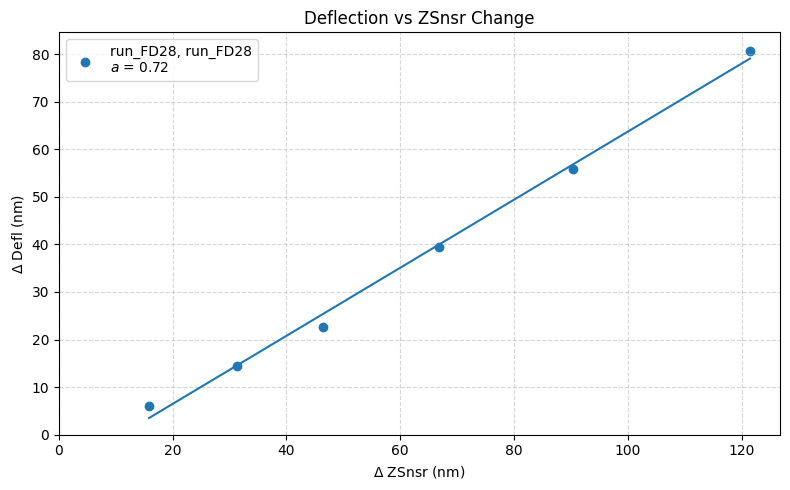

slope = 0.71508


In [246]:
data = {
    'x':{},
    'y':{},
    'slope':{},
    'intercept':{},
    'r':{},
}
legend = {}
for run in runs_to_plot:
    legend[run] = str(run)
for run in runs_to_plot:
    df_plot_run = df_plot[df_plot['run'] == run]
    data['x'][run] = df_plot_run['delta_z'].to_numpy()    * 1e9
    data['y'][run] = df_plot_run['delta_defl'].to_numpy() * 1e9
    mask = ~(np.isnan(data['x'][run]) | np.isnan(data['y'][run]))
    data['x'][run] = data['x'][run][mask]
    data['y'][run] = data['y'][run][mask]
    data['slope'][run], data['intercept'][run], data['r'][run], *_ = linregress(data['x'][run], data['y'][run])


fig, ax = plt.subplots(figsize=(8,5))

for run in runs_to_plot:
    x5 = data['x'][run]
    y5 = data['y'][run]
    slope5 = data['slope'][run]
    intercept5 = data['intercept'][run]
    ax.scatter(x5, y5, label=f'{run}, {legend[run]}\n$a$ = {slope5:.2f}')
    ax.plot(x5, slope5 * x5 + intercept5)

ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\Delta$ ZSnsr (nm)')
ax.set_ylabel(r'$\Delta$ Defl (nm)')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_title(f'Deflection vs ZSnsr Change')
plt.tight_layout()
plt.show()
print(f'slope = {slope5:.5f}')

In [245]:


fig = go.Figure()
for run in runs_to_plot:
    x5 = data['x'][run]
    y5 = data['y'][run]
    slope5 = data['slope'][run]
    intercept5 = data['intercept'][run]
    fig.add_trace(go.Scatter(x=x5, y=y5, mode='markers', name=f'{run}, {legend[run]}\n$a$ = {slope5:.2f}'))
    fig.add_trace(go.Scatter(x=x5, y=slope5 * x5 + intercept5, mode='lines', showlegend=False))

fig.update_layout(
    title='Deflection vs ZSnsr Change',
    xaxis_title=r'$\Delta$ ZSnsr (nm)',
    yaxis_title=r'$\Delta$ Defl (nm)',
)

fig.show()

In [173]:
fig = go.Figure()
for run in runs_to_plot:
    x5 = df_results[df_results['run'] == run]['force'].to_numpy() * 1e9   # → nN
    y5 = df_results[df_results['run'] == run]['delta_defl'].to_numpy() * 1e9  # → nm
    slope5, intercept5, *_ = linregress(x5, y5)
    fig.add_trace(go.Scatter(x=x5, y=y5, mode='markers', name=f'{run}, {legend[run]}\na = {slope5:.2f}'))
    fig.add_trace(go.Scatter(x=x5, y=slope5 * x5 + intercept5, mode='lines', showlegend=False))

fig.update_layout(
    title='Deflection vs Force',
    xaxis_title='Force (nN)',
    yaxis_title=r'$\Delta$ Defl (nm)',
)

fig.show()

## Step 6 – Fit Force vs. ΔDefl → spring constant *k*

In [74]:
x6 = df_results['delta_defl'] * 1e9   # -> nm
y6 = df_results['force']      * 1e6   # -> uN

slope6, intercept6, r6, *_ = linregress(x6, y6)
k = slope6 * 1e-6 / 1e-9              # uN/nm -> N/m

# Pull spec k values from config for each run
spec_labels = f'k = {config[EXAMPLE_RUN]["spring_constant_nominal"]}'

fig, ax = plt.subplots()
ax.scatter(x6, y6, color='red')
ax.plot(x6, slope6 * x6 + intercept6, color='red',
        label=f'$k_{{fit}}$ = {k:.2f} N/m\n{spec_labels}')
ax.set_xlabel(r'$\Delta$ Defl (nm)')
ax.set_ylabel(r'Force ($\mu$N)')
ax.set_title('Force vs Deflection')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Spring constant k = {k:.2f} N/m')

KeyError: 'spring_constant_nominal'